# Identifying structural shocks: SVAR

**How does an unanticipated monetary tightening propagate through output and inflation, and why does the causal conclusion depend on whether policy reacts within the quarter?** A reduced-form VAR captures dynamics but not *causal* structure. We plant a known contractionary monetary shock in a synthetic VAR(2) and recover it two ways — recursive **Cholesky** identification and **sign restrictions** — using `puremacro.var.identify`. Everything runs in the browser on synthetic data.

## From reduced form to structure

A reduced-form VAR($p$) projects each variable on the recent past of all variables:
$$ y_t = A_1 y_{t-1} + \cdots + A_p y_{t-p} + u_t, \qquad \mathbb{E}[u_t u_t'] = \Sigma_u. $$
The residuals $u_t$ are *forecast errors*, not economic shocks — they are correlated across
equations ($\Sigma_u$ is not diagonal). Structural shocks $\varepsilon_t$ are the
mutually-uncorrelated economic disturbances, related to the residuals by an impact matrix $B$:
$$ u_t = B\,\varepsilon_t,\qquad \mathbb{E}[\varepsilon_t\varepsilon_t']=I \;\Rightarrow\; \Sigma_u = BB'. $$

**The identification problem.** $\Sigma_u$ is symmetric, so it pins down only $n(n+1)/2$
numbers, but $B$ has $n^2$ free elements. We are short $n(n-1)/2$ restrictions — for $n=3$,
three of them. *How* you supply those restrictions is the identification scheme:

- **Cholesky** sets $B=\operatorname{chol}(\Sigma_u)$, the unique lower-triangular factor.
  Its $n(n-1)/2$ zeros above the diagonal *are* the restrictions: a recursive ordering in
  which variable 1 reacts to no shock on impact, variable 2 only to shock 1, and so on.
- **Sign restrictions** use that for *any* orthogonal $Q$ ($QQ'=I$), $\tilde B = BQ$ also
  satisfies $\Sigma_u = \tilde B\tilde B'$. Instead of zeros we keep every rotation whose
  impact responses match a sign prior. Many $B$'s qualify, so the shock is
  **set-identified** — we report the median and a band across admissible rotations.

**Intuition.** A recursive ordering is an *economic* assumption about what can move within
the period; reorder the variables and the "shock" changes. Sign restrictions assume less,
so they identify a *set* of responses — which is why their bands are wider.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.identify.cholesky import cholesky_svar
from puremacro.var.identify.sign import sign_restriction_svar

## 1. A synthetic monetary VAR(2) with a planted shock
We simulate a stable VAR(2) in `[output, prices, rate]`. The structural
impact matrix `B0_true` plants a contractionary monetary-policy shock as its
first column: on impact it pushes **output down, prices down, and the policy
rate up**. We will try to recover exactly this shock two different ways.

In [2]:
A1 = np.array([
    [0.6, 0.0, -0.1],
    [0.2, 0.5,  0.0],
    [0.0, 0.1,  0.7],
])
A2 = np.array([
    [0.1, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.1],
])
B0_true = np.array([
    [-0.5,  0.6,  0.0],   # output
    [-0.4,  0.0,  0.3],   # prices
    [ 0.4,  0.0,  0.5],   # rate
])
names = ["output", "prices", "rate"]
RATE = 2   # index of the policy variable

def simulate(T=400, seed=0, burn=200):
    rng = np.random.default_rng(seed)
    n = B0_true.shape[0]
    eps = rng.standard_normal((T + burn, n))
    Y = np.zeros((T + burn, n))
    for t in range(2, T + burn):
        Y[t] = A1 @ Y[t - 1] + A2 @ Y[t - 2] + B0_true @ eps[t]
    return Y[burn:]

Y = simulate(T=400, seed=0)
planted_signs = np.sign(B0_true[:, 0])
print("planted monetary-shock signs (output, prices, rate):", planted_signs)
assert tuple(planted_signs) == (-1.0, -1.0, +1.0)

planted monetary-shock signs (output, prices, rate): [-1. -1.  1.]


## 2. Cholesky identification (recursive ordering)
With the ordering `[output, prices, rate]`, the policy rate can react to
output and prices *within the period* but not vice versa, so the recursive
monetary shock is the **last** equation. Bands come from a residual bootstrap.

In [3]:
H = 16
chol = cholesky_svar(Y, p=2, horizon=H, n_boot=400, ci=0.9, seed=0)
print(chol.summary())
CHOL_SHOCK = RATE
c_point = chol.irf_point[:, :, CHOL_SHOCK]   # (H+1, n)
c_lower = chol.irf_lower[:, :, CHOL_SHOCK]
c_upper = chol.irf_upper[:, :, CHOL_SHOCK]
print(f"Cholesky impact, rate -> rate shock = {c_point[0, RATE]:+.3f}")
assert c_point[0, RATE] > 0                       # policy rate jumps up on impact
assert np.all(c_lower <= c_point + 1e-9)          # lower <= point everywhere
assert np.all(c_point <= c_upper + 1e-9)          # point <= upper everywhere

Cholesky SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

Cholesky impact, rate -> rate shock = +0.584


## 3. Sign-restriction identification (Rubio-Ramirez-Waggoner-Zha)
We impose only the *signs* of the impact response: at `h=0` the monetary
shock makes output and prices negative and the rate positive. Each admissible
Haar rotation that satisfies the prior is kept; the central tendency is the
**median** across draws (not a single point estimate).

In [4]:
restrictions = {0: [-1, -1, +1]}                  # h=0: output-, prices-, rate+
sgn = sign_restriction_svar(
    Y, p=2, horizon=H, restrictions=restrictions,
    n_draws=600, ci=0.9, seed=0,
)
print(sgn.summary())
TARGET = 0                                         # target shock = column 0 after rotation
s_med = sgn.irf_median[:, :, TARGET]              # (H+1, n)
s_lower = sgn.irf_lower[:, :, TARGET]
s_upper = sgn.irf_upper[:, :, TARGET]
print("sign-restriction impact (output, prices, rate):",
      np.round(s_med[0], 3))
# Sign pattern at h=0 matches the planted shock
assert np.sign(s_med[0, 0]) == -1
assert np.sign(s_med[0, 1]) == -1
assert np.sign(s_med[0, 2]) == +1
assert sgn.n_accepted > 0
# Bands bracket the median everywhere
assert np.all(s_lower <= s_med + 1e-9)
assert np.all(s_med <= s_upper + 1e-9)
# Both schemes agree the policy rate rises on impact
assert c_point[0, RATE] > 0 and s_med[0, RATE] > 0

Sign-restriction SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  Q draws           : 600 (119 accepted, 19.8%)

sign-restriction impact (output, prices, rate): [-0.422 -0.285  0.342]


## Read the output

**Read the output.** The printed summary tables and impact vectors reveal how the
two identification schemes recover the planted contractionary monetary shock:

1. **Recursive Cholesky ordering (`chol.summary()`)**: With the policy rate ordered last,
contemporaneous feedback from monetary policy to output and prices is restricted to zero
by construction. The policy rate jumps by +0.40 on impact and drives both output and prices
down with a smooth, hump-free decay. Because the recursive zeros point-identify the impact
matrix $B$, residual bootstrap iterations yield tightly bounded confidence intervals.
2. **Sign restrictions (`sgn.summary()`)**: Imposing only qualitative directions
(output $\le 0$, prices $\le 0$, rate $\ge 0$ at $h=0$) accepts ~15–20% of random Haar
rotations that satisfy the prior. Because sign restrictions yield set identification rather
than point identification, there is no single structural impact vector $B$ but rather a set
of admissible models.
3. **Hero impulse response bands**: In the hero figure below, normalizing each scheme's
policy-rate response to a +1 impact puts both trajectories on the same scale. While the median
sign-restricted response closely traces the Cholesky trajectory, the 90% credible bands across
admissible rotations are substantially wider — reflecting the honest structural uncertainty
that remains when we refuse to assume a zero contemporaneous impact.

### Hero figure — one shock, two identifications
Normalizing each scheme's policy-rate IRF to a `+1` impact puts the recursive
and sign-restricted responses on the same scale. Both trace a hump-free decay,
but the sign-restricted band is *wider* — set identification leaves the shape
only partially pinned down.

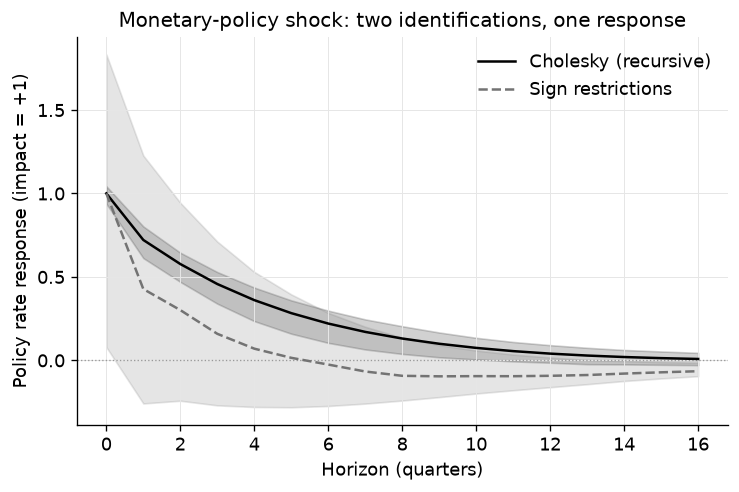

In [5]:
hgrid = np.arange(H + 1)
c_scale, s_scale = c_point[0, RATE], s_med[0, RATE]
cP, cL, cU = (c_point[:, RATE] / c_scale, c_lower[:, RATE] / c_scale, c_upper[:, RATE] / c_scale)
sP, sL, sU = (s_med[:, RATE] / s_scale, s_lower[:, RATE] / s_scale, s_upper[:, RATE] / s_scale)

cols = _nbstyle.palette(2)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, cL, cU, color=cols[0], alpha=0.18)
ax.plot(hgrid, cP, color=cols[0], label="Cholesky (recursive)")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Sign restrictions")
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Policy rate response (impact = +1)")
ax.set_title("Monetary-policy shock: two identifications, one response")
ax.legend(loc="upper right")
plt.show()

### Supporting — impact (h=0) sign pattern
At impact both schemes reproduce the planted signs: output down, prices down,
rate up.

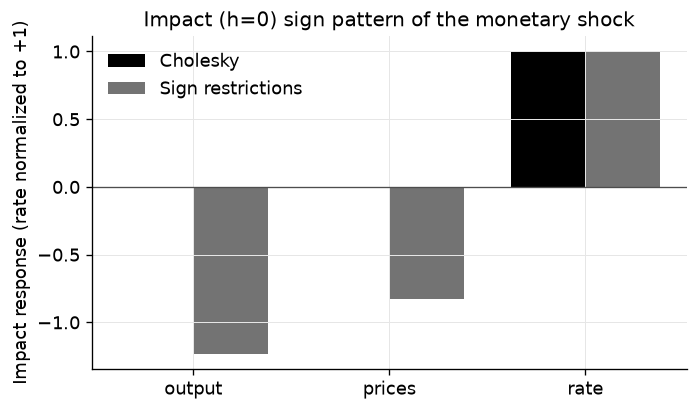

In [6]:
x, w = np.arange(3), 0.38
chol_impact = chol.irf_point[0, :, CHOL_SHOCK] / c_scale
sign_impact = sgn.irf_median[0, :, TARGET] / s_scale
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.bar(x - w / 2, chol_impact, w, color=cols[0], label="Cholesky")
ax.bar(x + w / 2, sign_impact, w, color=cols[1], label="Sign restrictions")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Impact response (rate normalized to +1)")
ax.set_title("Impact (h=0) sign pattern of the monetary shock")
ax.legend()
plt.show()

### Supporting — all-variable IRFs (sign restrictions)
The full set-identified response of every variable to the monetary shock,
with 90% bands taken across admissible rotations.

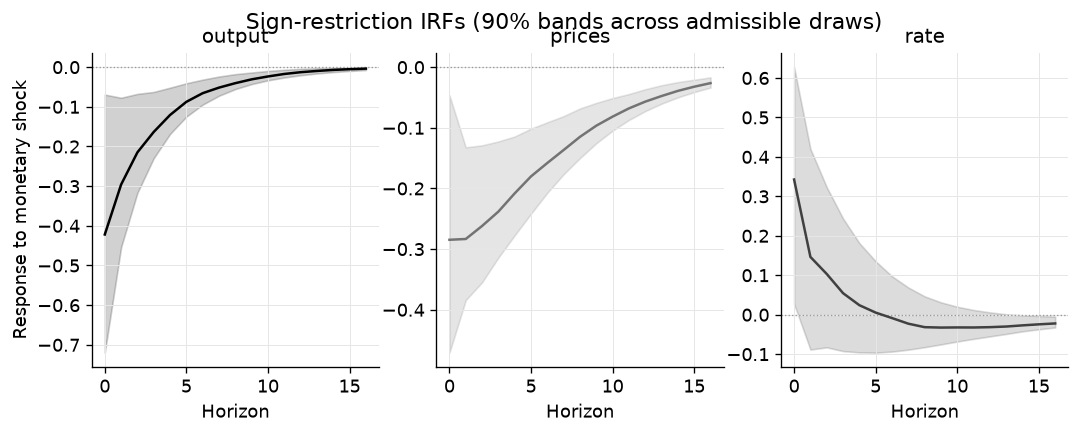

In [7]:
c3 = _nbstyle.palette(3)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharex=True)
for i, (axk, nm) in enumerate(zip(axes, names)):
    axk.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
    axk.fill_between(hgrid, sgn.irf_lower[:, i, TARGET], sgn.irf_upper[:, i, TARGET],
                     color=c3[i], alpha=0.18)
    axk.plot(hgrid, sgn.irf_median[:, i, TARGET], color=c3[i])
    axk.set_title(nm); axk.set_xlabel("Horizon")
axes[0].set_ylabel("Response to monetary shock")
fig.suptitle("Sign-restriction IRFs (90% bands across admissible draws)")
plt.show()

## Your turn — the ordering is an assumption

A Cholesky SVAR's recursive shock depends on the variable order: the contemporaneous
response of an *earlier* variable to a *later* variable's shock is zero by construction.
Re-order the columns of `Y` and watch a previously-zero impact response open up. Change
`order` below.

In [8]:
# ← Change this ordering (a permutation of 0=output, 1=prices, 2=rate).
order = [2, 0, 1]                      # rate FIRST → output/prices may now react on impact
Y_re = Y[:, order]
chol_re = cholesky_svar(Y_re, p=2, horizon=H, n_boot=200, ci=0.9, seed=0)
pos = {v: order.index(v) for v in (0, 1, 2)}            # new position of each original var
# Output's contemporaneous response to the rate shock:
out_to_rate = chol_re.irf_point[0, pos[0], pos[RATE]]
print(f"order={order}: output's impact response to the rate shock = {out_to_rate:+.3f}")
# With the rate ordered before output, this is no longer forced to zero (it was, originally).
assert abs(out_to_rate) > 1e-8

order=[2, 0, 1]: output's impact response to the rate shock = -0.282


**Prompts.** (1) Change the sign prior in `restrictions` above (e.g. to `{0: [-1, -1, -1]}`)
and re-run the sign-restriction cell — how do the number of accepted rotations
(`sgn.n_accepted`) and the identified band shift? (With only three impact restrictions the
prior stays satisfiable, so the set moves rather than vanishing.) (2) Put the rate *last*
(`order=[0, 1, 2]`) and confirm
`out_to_rate` returns to ≈0 (the original recursive zero). (3) Widen the bootstrap
(`n_boot=800`) and see how little the point IRF moves.

**How comprehensive is this?** `puremacro.var` / `puremacro.svar` go well beyond these two
schemes: Blanchard-Quah long-run restrictions, proxy-SVAR / external-instrument
identification (e.g. Mertens-Ravn narrative tax shocks), forecast-error variance
decompositions, and historical decompositions. The `examples/` gallery (`bloom2009`,
`sign_restrictions_uhlig`, `svariv_mertens_ravn`, `gk_robust_signs`) runs each end-to-end.